# PPE Dataset EDA

This notebook inspects the PPE detection dataset before modeling. I am checking the dataset structure, annotation coverage, class balance, image sizes, bounding-box geometry, and examples that may need manual review.

The current export has **1,644 images** and **4,298 valid annotation rows** across **4 classes**: glove, helmet, pants, vest.


**Before running this notebook, download the dataset into the `datasets/` directory. Information regarding the dataset and the structure of the data is in ../datasets/data.yaml.** 

Dataset: Roboflow PPE dataset exported in YOLOv11 format.  
Source: `https://universe.roboflow.com/ppe1-qla6c/ppe-gzzdx/dataset/2`

Expected local structure:  
datasets/  
  &emsp;train/images  
  &emsp;train/labels  
  &emsp;valid/images  
  &emsp;valid/labels  
  &emsp;test/images  
  &emsp;test/labels  
  &emsp;data.yaml

## Setup

In [1]:
from pathlib import Path
import math
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "data_inspection_eda"} else Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

DATASET_ROOT = PROJECT_ROOT / "datasets"

SPLITS = ["train", "valid", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CLASS_COLORS_BGR = [
    (22, 163, 74),
    (37, 99, 235),
    (249, 115, 22),
    (168, 85, 247),
    (14, 165, 233),
    (239, 68, 68),
]

pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Dataset root: {DATASET_ROOT}")


Matplotlib is building the font cache; this may take a moment.


Dataset root: /Users/joshabel/Desktop/CurrentResume/Resumes_in_Reichman/github-projects/MLOps_PPE_pipeline/ppe_safety_detector/datasets


## Dataset Configuration

In [3]:
with open(DATASET_ROOT / "data.yaml", "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

class_names = list(data_cfg["names"])
num_classes = int(data_cfg["nc"])

print(f"Classes ({num_classes}): {class_names}")
data_cfg


Classes (4): ['glove', 'helmet', 'pants', 'vest']


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 4,
 'names': ['glove', 'helmet', 'pants', 'vest'],
 'roboflow': {'workspace': 'ppe1-qla6c',
  'project': 'ppe-gzzdx',
  'version': 2,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/ppe1-qla6c/ppe-gzzdx/dataset/2'}}

## Parsing Helpers

The label parser accepts standard YOLO bounding-box rows and polygon-style YOLO rows. For polygon rows, I use the polygon extent as the detection bounding box.

In [4]:
def image_files(split):
    image_dir = DATASET_ROOT / split / "images"
    return sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])


def label_path_for(split, image_path):
    return DATASET_ROOT / split / "labels" / f"{image_path.stem}.txt"


def parse_label_file(label_path, class_names):
    boxes = []
    issues = []

    if not label_path.exists():
        return boxes, ["missing_label_file"]

    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return boxes, ["empty_label_file"]

    for line_number, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        if len(parts) == 5:
            annotation_type = "box"
        elif len(parts) >= 7 and len(parts[1:]) % 2 == 0:
            annotation_type = "polygon"
        else:
            issues.append(f"malformed_line_{line_number}")
            continue

        try:
            class_id = int(float(parts[0]))
            coords = [float(v) for v in parts[1:]]
        except ValueError:
            issues.append(f"non_numeric_line_{line_number}")
            continue

        if class_id < 0 or class_id >= len(class_names):
            issues.append(f"class_out_of_range_line_{line_number}")
            continue

        if annotation_type == "box":
            x_center, y_center, width, height = coords
            polygon_points = 0
        else:
            xs = coords[0::2]
            ys = coords[1::2]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2
            width = x_max - x_min
            height = y_max - y_min
            polygon_points = len(xs)

        if not all(0 <= v <= 1 for v in [x_center, y_center, width, height]) or width <= 0 or height <= 0:
            issues.append(f"invalid_normalized_geometry_line_{line_number}")

        boxes.append({
            "class_id": class_id,
            "class_name": class_names[class_id],
            "annotation_type": annotation_type,
            "polygon_points": polygon_points,
            "x_center": x_center,
            "y_center": y_center,
            "width_norm": width,
            "height_norm": height,
            "area_norm": width * height,
        })

    return boxes, issues


def build_dataset_audit(class_names):
    image_rows = []
    box_rows = []
    issue_rows = []

    for split in SPLITS:
        for image_path in image_files(split):
            label_path = label_path_for(split, image_path)
            image = cv2.imread(str(image_path))
            if image is None:
                width = height = np.nan
                issue_rows.append({"split": split, "image": image_path.name, "issue": "image_read_error"})
            else:
                height, width = image.shape[:2]

            boxes, issues = parse_label_file(label_path, class_names)
            image_rows.append({
                "split": split,
                "image": image_path.name,
                "image_path": str(image_path),
                "label_path": str(label_path),
                "width": width,
                "height": height,
                "image_size": f"{int(width)}x{int(height)}" if pd.notna(width) else "unreadable",
                "has_label_file": label_path.exists(),
                "is_empty_label": label_path.exists() and label_path.stat().st_size == 0,
                "object_count": len(boxes),
                "class_count": len({box["class_id"] for box in boxes}),
                "issues": ";".join(issues),
            })

            for issue in issues:
                issue_rows.append({"split": split, "image": image_path.name, "issue": issue})

            for box_index, box in enumerate(boxes):
                box_rows.append({
                    "split": split,
                    "image": image_path.name,
                    "image_path": str(image_path),
                    "label_path": str(label_path),
                    "box_index": box_index,
                    "image_width": width,
                    "image_height": height,
                    **box,
                })

    return pd.DataFrame(image_rows), pd.DataFrame(box_rows), pd.DataFrame(issue_rows)


## Build the Audit Tables

In [6]:
image_df, box_df, issue_df = build_dataset_audit(class_names)

print(f"Images: {len(image_df):,}")
print(f"Annotation rows: {len(box_df):,}")
print(f"Label/image issues: {len(issue_df):,}")

display(image_df.head())
display(box_df.head())


Images: 1,644
Annotation rows: 4,298
Label/image issues: 0


,split,image,image_path,label_path,width,height,image_size,has_label_file,is_empty_label,object_count,class_count,issues
0,train,-_image_110_jpg.rf.a7b39d29d4c2783c2b0c91eb0c2...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,640,640,640x640,True,False,1,1,
1,train,-_image_111_jpg.rf.699c7c5eb257f7f2510ed149298...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,640,640,640x640,True,False,2,1,
2,train,-_image_115_jpg.rf.12949e330c4382ff417e7ccc767...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,640,640,640x640,True,False,3,1,
3,train,-_image_121_jpg.rf.b4bc69c19345005047de4853c4b...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,640,640,640x640,True,False,1,1,
4,train,-_image_132_jpg.rf.d2d3a9dc76077fa0e56cb2df21a...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,640,640,640x640,True,False,1,1,


,split,image,image_path,label_path,box_index,image_width,image_height,class_id,class_name,annotation_type,polygon_points,x_center,y_center,width_norm,height_norm,area_norm
0,train,-_image_110_jpg.rf.a7b39d29d4c2783c2b0c91eb0c2...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,0,640,640,2,pants,box,0,0.489844,0.528125,0.278906,0.817187,0.227919
1,train,-_image_111_jpg.rf.699c7c5eb257f7f2510ed149298...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,0,640,640,2,pants,box,0,0.284375,0.471875,0.259375,0.796875,0.206689
2,train,-_image_111_jpg.rf.699c7c5eb257f7f2510ed149298...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,1,640,640,2,pants,box,0,0.742969,0.471094,0.216406,0.814063,0.176168
3,train,-_image_115_jpg.rf.12949e330c4382ff417e7ccc767...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,0,640,640,2,pants,box,0,0.171875,0.496094,0.341406,0.992188,0.338739
4,train,-_image_115_jpg.rf.12949e330c4382ff417e7ccc767...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,/Users/joshabel/Desktop/CurrentResume/Resumes_...,1,640,640,2,pants,box,0,0.508594,0.491406,0.329688,0.982812,0.324021


## Split Size

I start by checking whether the train, validation, and test splits are present and sized as expected.

,split,images,labels,mean_labels_per_image,median_labels_per_image,max_labels_in_image
0,train,1152,3011,2.61,2.0,27
1,valid,328,813,2.48,2.0,13
2,test,164,474,2.89,2.0,16


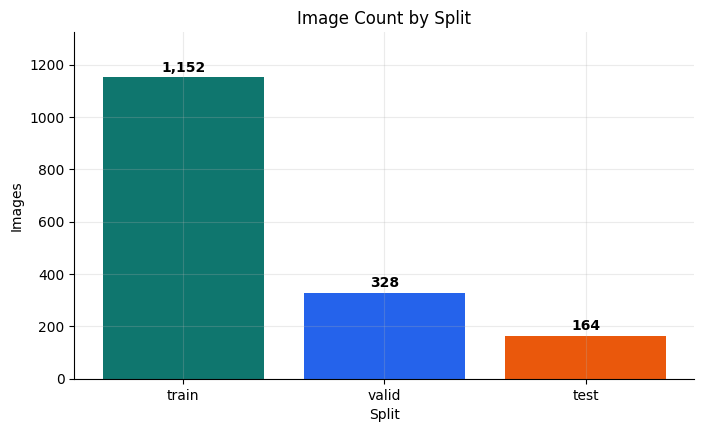

In [7]:
split_summary = (
    image_df.groupby("split")
    .agg(
        images=("image", "count"),
        labels=("object_count", "sum"),
        mean_labels_per_image=("object_count", "mean"),
        median_labels_per_image=("object_count", "median"),
        max_labels_in_image=("object_count", "max"),
    )
    .reindex(SPLITS)
    .reset_index()
)
split_summary["mean_labels_per_image"] = split_summary["mean_labels_per_image"].round(2)

display(split_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#0F766E", "#2563EB", "#EA580C"]
ax.bar(split_summary["split"], split_summary["images"], color=colors)
ax.set_title("Image Count by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Images")
for idx, value in enumerate(split_summary["images"]):
    ax.text(idx, value + max(split_summary["images"]) * 0.02, f"{int(value):,}", ha="center", fontweight="bold")
ax.set_ylim(0, max(split_summary["images"]) * 1.15)
plt.show()


## Class Balance

Class balance matters because underrepresented classes usually need closer inspection and may need more examples later.

split,class_name,train,valid,test,total
0,glove,904,256,133,1293
1,helmet,697,174,111,982
2,pants,630,171,108,909
3,vest,780,212,122,1114


Most common class: glove (1,293 labels)
Least common class: pants (909 labels)
Imbalance ratio: 1.42:1


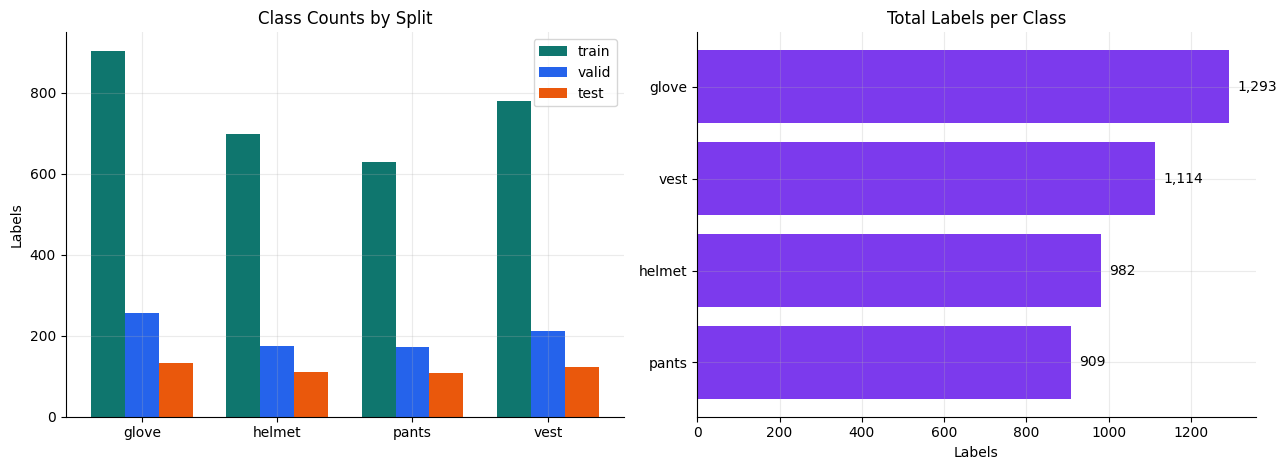

In [8]:
class_counts = (
    box_df.pivot_table(index="class_name", columns="split", values="box_index", aggfunc="count", fill_value=0)
    .reindex(class_names)
    .fillna(0)
    .astype(int)
    .reset_index()
)
for split in SPLITS:
    if split not in class_counts:
        class_counts[split] = 0
class_counts["total"] = class_counts[SPLITS].sum(axis=1)
class_counts = class_counts[["class_name", *SPLITS, "total"]]

display(class_counts)

largest = class_counts.sort_values("total", ascending=False).iloc[0]
smallest = class_counts.sort_values("total", ascending=True).iloc[0]
print(
    f"Most common class: {largest.class_name} ({largest.total:,} labels)\n"
    f"Least common class: {smallest.class_name} ({smallest.total:,} labels)\n"
    f"Imbalance ratio: {largest.total / smallest.total:.2f}:1"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(class_counts))
width = 0.25
colors = {"train": "#0F766E", "valid": "#2563EB", "test": "#EA580C"}
for offset, split in zip([-width, 0, width], SPLITS):
    axes[0].bar(x + offset, class_counts[split], width=width, label=split, color=colors[split])
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_counts["class_name"])
axes[0].set_title("Class Counts by Split")
axes[0].set_ylabel("Labels")
axes[0].legend()

ordered = class_counts.sort_values("total", ascending=True)
axes[1].barh(ordered["class_name"], ordered["total"], color="#7C3AED")
axes[1].set_title("Total Labels per Class")
axes[1].set_xlabel("Labels")
for i, value in enumerate(ordered["total"]):
    axes[1].text(value + ordered["total"].max() * 0.015, i, f"{int(value):,}", va="center")
plt.tight_layout()
plt.show()


## Label File and Annotation Format Checks

This catches missing labels, empty labels, malformed rows, and mixed annotation formats before any modeling work.

,split,images,missing_label_files,empty_label_files,flagged_label_rows
0,train,1152,0,0,0
1,valid,328,0,0,0
2,test,164,0,0,0


split,annotation_type,test,train,valid,total
0,box,454,2862,764,4080
1,polygon,20,149,49,218


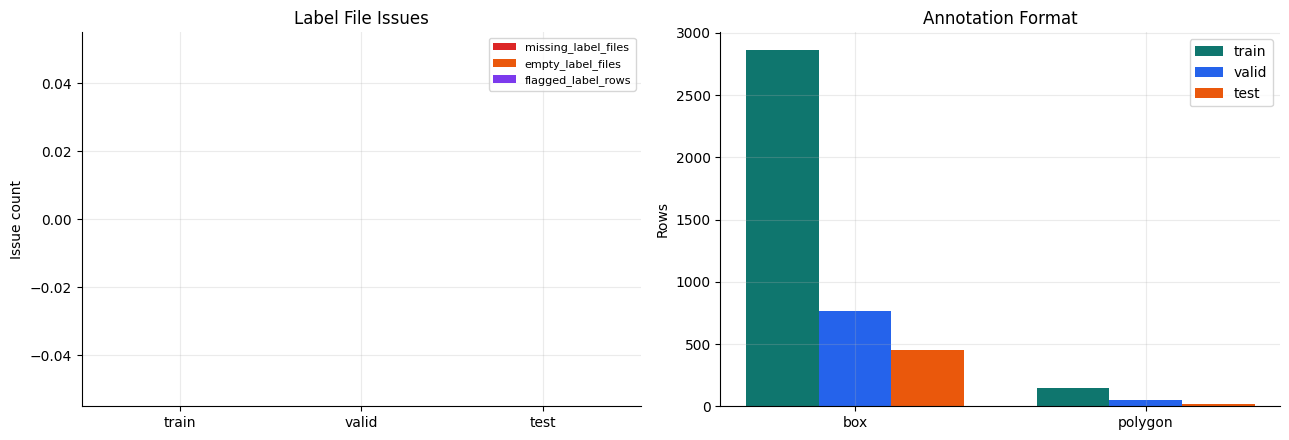

In [9]:
quality_summary = pd.DataFrame([
    {
        "split": split,
        "images": int((image_df["split"] == split).sum()),
        "missing_label_files": int(((image_df["split"] == split) & (~image_df["has_label_file"])).sum()),
        "empty_label_files": int(((image_df["split"] == split) & (image_df["is_empty_label"])).sum()),
        "flagged_label_rows": int((issue_df["split"] == split).sum()) if not issue_df.empty else 0,
    }
    for split in SPLITS
])

annotation_summary = (
    box_df.pivot_table(index="annotation_type", columns="split", values="box_index", aggfunc="count", fill_value=0)
    .reindex(["box", "polygon"])
    .fillna(0)
    .astype(int)
    .reset_index()
)
annotation_summary["total"] = annotation_summary[SPLITS].sum(axis=1)

display(quality_summary)
display(annotation_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
quality_cols = ["missing_label_files", "empty_label_files", "flagged_label_rows"]
bottom = np.zeros(len(quality_summary))
colors = ["#DC2626", "#EA580C", "#7C3AED"]
for col, color in zip(quality_cols, colors):
    axes[0].bar(quality_summary["split"], quality_summary[col], bottom=bottom, label=col, color=color)
    bottom += quality_summary[col].to_numpy()
axes[0].set_title("Label File Issues")
axes[0].set_ylabel("Issue count")
axes[0].legend(fontsize=8)

x = np.arange(len(annotation_summary))
width = 0.25
for offset, split, color in zip([-width, 0, width], SPLITS, ["#0F766E", "#2563EB", "#EA580C"]):
    axes[1].bar(x + offset, annotation_summary[split], width=width, label=split, color=color)
axes[1].set_title("Annotation Format")
axes[1].set_xticks(x)
axes[1].set_xticklabels(annotation_summary["annotation_type"])
axes[1].set_ylabel("Rows")
axes[1].legend()
plt.tight_layout()
plt.show()


## Image Size Distribution

The dataset README says the export was resized to 640x640. I verify that directly from the image files.

,image_size,images
0,640x640,1644


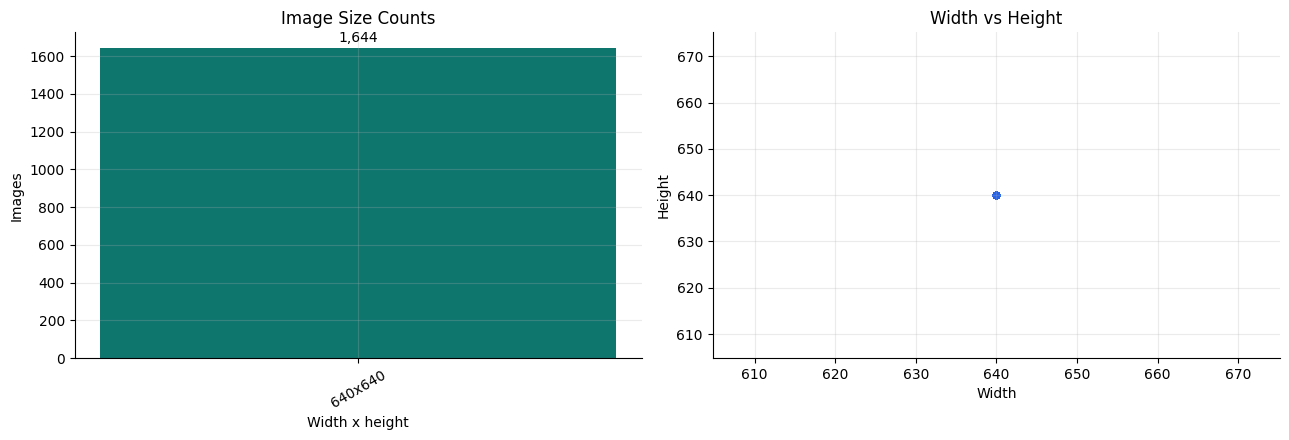

In [10]:
size_summary = image_df["image_size"].value_counts().rename_axis("image_size").reset_index(name="images")
display(size_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(size_summary["image_size"], size_summary["images"], color="#0F766E")
axes[0].set_title("Image Size Counts")
axes[0].set_xlabel("Width x height")
axes[0].set_ylabel("Images")
axes[0].tick_params(axis="x", rotation=30)
for idx, value in enumerate(size_summary["images"]):
    axes[0].text(idx, value + max(size_summary["images"]) * 0.02, f"{int(value):,}", ha="center")

axes[1].scatter(image_df["width"], image_df["height"], alpha=0.35, s=18, c="#2563EB")
axes[1].set_title("Width vs Height")
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Height")
plt.tight_layout()
plt.show()


## Object Density

Images with many labels can be useful but also harder to inspect, especially when objects overlap or are far from the camera.

,statistic,object_count
0,count,1644.000000
1,mean,2.614355
2,std,2.018403
3,min,1.000000
4,25%,1.000000
5,50%,2.000000
6,75%,4.000000
7,90%,5.000000
8,95%,5.000000
9,max,27.000000


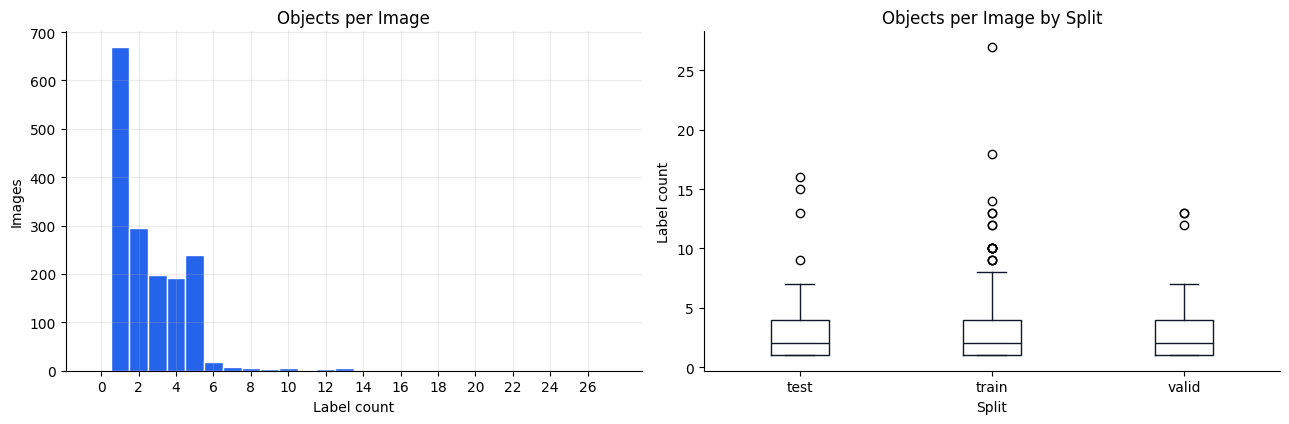

In [11]:
object_percentiles = (
    image_df["object_count"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .rename("object_count")
    .reset_index()
    .rename(columns={"index": "statistic"})
)
display(object_percentiles)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
max_objects = int(image_df["object_count"].max())
bins = np.arange(0, max_objects + 2) - 0.5
axes[0].hist(image_df["object_count"], bins=bins, color="#2563EB", edgecolor="white")
axes[0].set_title("Objects per Image")
axes[0].set_xlabel("Label count")
axes[0].set_ylabel("Images")
axes[0].set_xticks(range(0, max_objects + 1, max(1, max_objects // 10)))

image_df.boxplot(column="object_count", by="split", ax=axes[1], grid=False, color="#111827")
axes[1].set_title("Objects per Image by Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Label count")
fig.suptitle("")
plt.tight_layout()
plt.show()


## Bounding-Box Geometry

Box width, height, and area distributions help reveal tiny-object cases and broad differences between classes.

,statistic,box_area_percent
0,count,4298.000000
1,mean,12.548946
2,std,20.714850
3,min,0.001404
4,25%,1.072266
5,50%,4.279846
6,75%,11.230835
7,90%,38.544629
8,95%,63.653650
9,max,99.687744


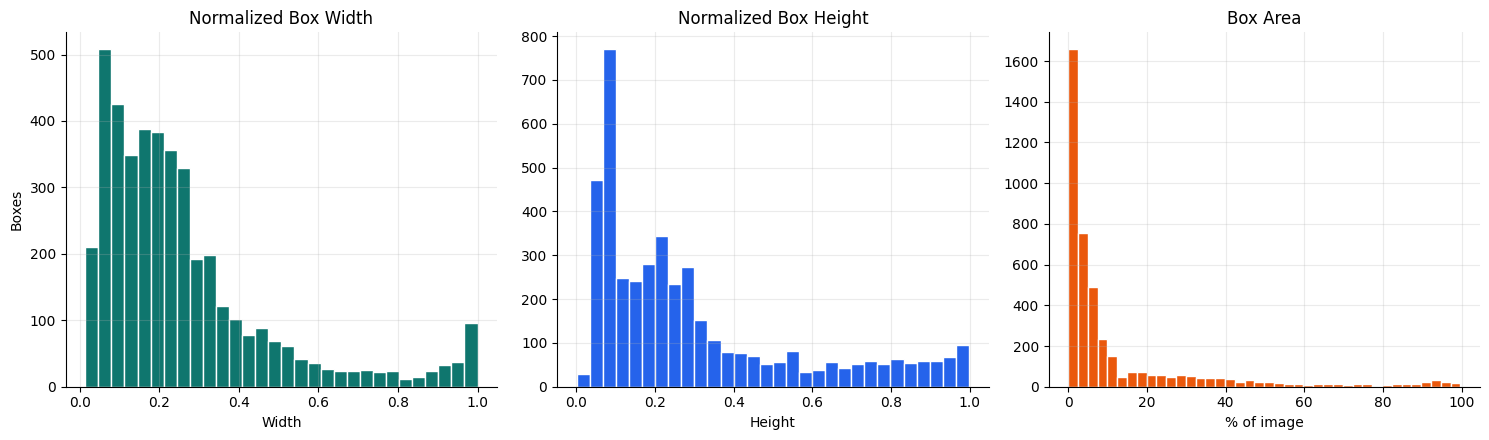

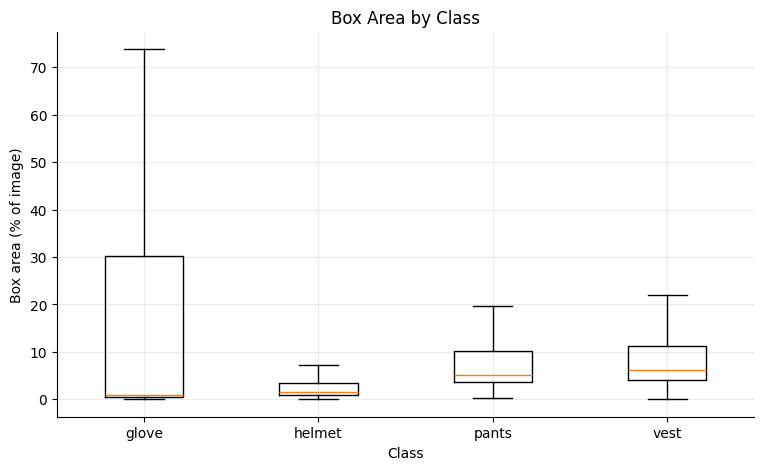

In [12]:
area_summary = (
    (box_df["area_norm"] * 100)
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .rename("box_area_percent")
    .reset_index()
    .rename(columns={"index": "statistic"})
)
display(area_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(box_df["width_norm"], bins=30, color="#0F766E", edgecolor="white")
axes[0].set_title("Normalized Box Width")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Boxes")

axes[1].hist(box_df["height_norm"], bins=30, color="#2563EB", edgecolor="white")
axes[1].set_title("Normalized Box Height")
axes[1].set_xlabel("Height")

axes[2].hist(box_df["area_norm"] * 100, bins=40, color="#EA580C", edgecolor="white")
axes[2].set_title("Box Area")
axes[2].set_xlabel("% of image")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
classes = sorted(box_df["class_name"].unique())
area_by_class = [box_df.loc[box_df["class_name"] == cls, "area_norm"] * 100 for cls in classes]
ax.boxplot(area_by_class, tick_labels=classes, showfliers=False)
ax.set_title("Box Area by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Box area (% of image)")
plt.show()


## Display Images With Bounding Boxes

These are raw dataset examples with their annotations drawn on top. I use this as a visual sanity check for label tightness, class definitions, and scene variety.

In [13]:
def box_to_xyxy(box, image_width, image_height):
    x_center = float(box["x_center"]) * image_width
    y_center = float(box["y_center"]) * image_height
    box_width = float(box["width_norm"]) * image_width
    box_height = float(box["height_norm"]) * image_height
    x1 = max(0, int(x_center - box_width / 2))
    y1 = max(0, int(y_center - box_height / 2))
    x2 = min(image_width - 1, int(x_center + box_width / 2))
    y2 = min(image_height - 1, int(y_center + box_height / 2))
    return x1, y1, x2, y2


def draw_boxes_on_image(image_path, boxes, class_names):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    h, w = image_bgr.shape[:2]
    canvas = image_bgr.copy()
    for _, box in boxes.iterrows():
        class_id = int(box["class_id"])
        color = CLASS_COLORS_BGR[class_id % len(CLASS_COLORS_BGR)]
        x1, y1, x2, y2 = box_to_xyxy(box, w, h)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)

        label = class_names[class_id]
        (text_w, text_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.48, 1)
        label_y = max(0, y1 - text_h - baseline - 4)
        cv2.rectangle(canvas, (x1, label_y), (x1 + text_w + 8, label_y + text_h + baseline + 6), color, -1)
        cv2.putText(
            canvas,
            label,
            (x1 + 4, label_y + text_h + 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.48,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

    return cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)


def show_image_grid(selections, title, columns=3, figsize=(15, 9)):
    rows = math.ceil(len(selections) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(rows, columns)
    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.99)

    for ax in axes.ravel():
        ax.axis("off")

    for ax, item in zip(axes.ravel(), selections):
        image_path = item["image_path"]
        image_boxes = box_df[box_df["image_path"] == str(image_path)]
        annotated = draw_boxes_on_image(image_path, image_boxes, class_names)
        ax.imshow(annotated)
        ax.set_title(item["caption"], fontsize=10, loc="left")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


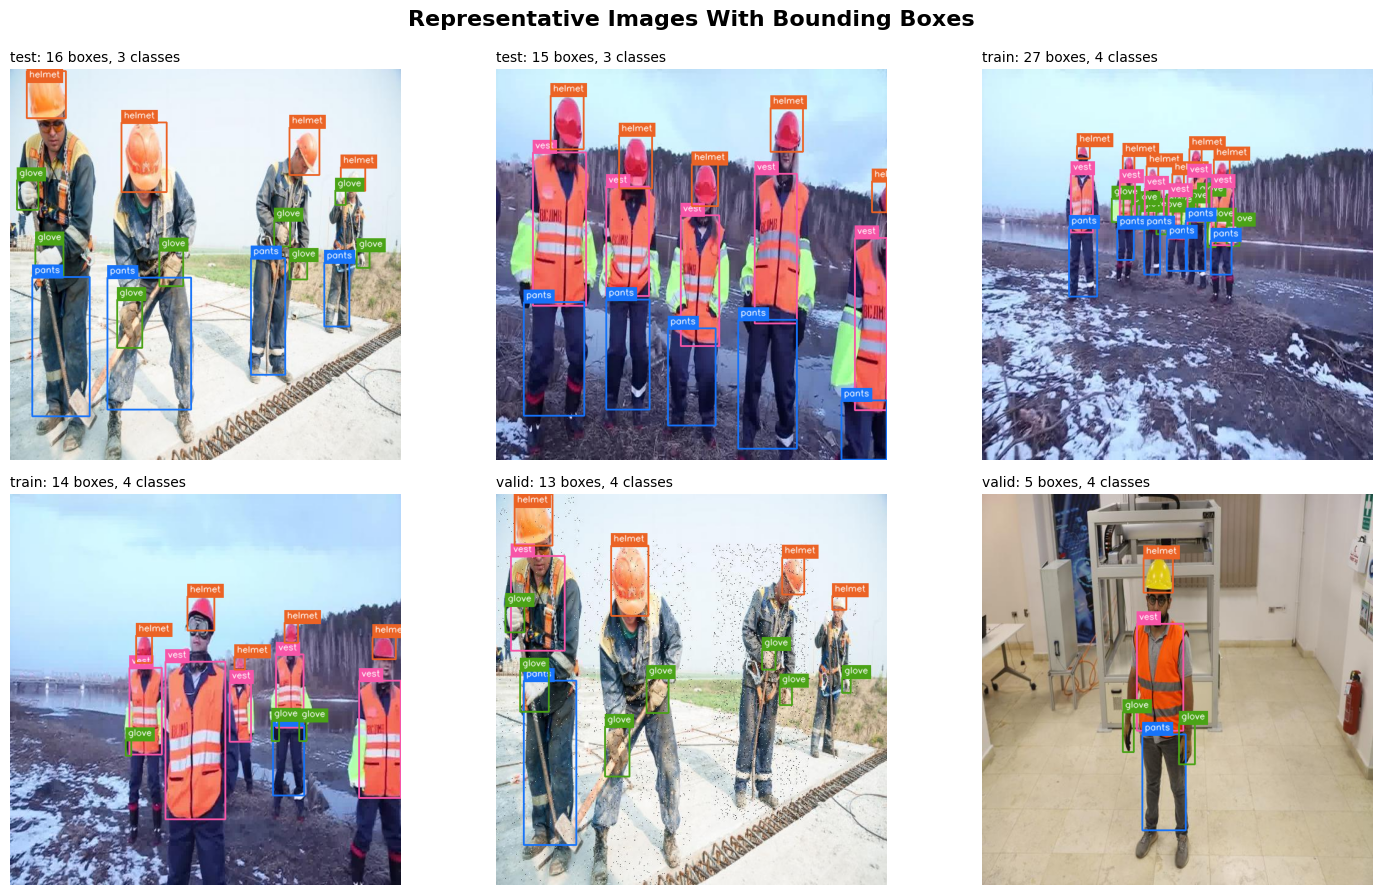

In [14]:
candidates = image_df[(image_df["object_count"] >= 2) & (image_df["class_count"] >= 2)].copy()
candidates["selection_score"] = candidates["class_count"] * 10 + candidates["object_count"]
selected = (
    candidates.sort_values(["split", "selection_score", "image"], ascending=[True, False, True])
    .groupby("split")
    .head(2)
)

example_images = [
    {
        "image_path": Path(row.image_path),
        "caption": f"{row.split}: {int(row.object_count)} boxes, {int(row.class_count)} classes",
    }
    for row in selected.itertuples()
][:6]

show_image_grid(example_images, "Representative Images With Bounding Boxes", columns=3, figsize=(15, 9))


## Examples Worth Manual Review

I also pull a few examples based on simple heuristics: dense scenes, tiny boxes, overlapping boxes, and the least frequent class. These are not necessarily wrong; they are just worth looking at before modeling.

In [15]:
def compute_iou(box_a, box_b):
    ax1 = box_a["x_center"] - box_a["width_norm"] / 2
    ay1 = box_a["y_center"] - box_a["height_norm"] / 2
    ax2 = box_a["x_center"] + box_a["width_norm"] / 2
    ay2 = box_a["y_center"] + box_a["height_norm"] / 2
    bx1 = box_b["x_center"] - box_b["width_norm"] / 2
    by1 = box_b["y_center"] - box_b["height_norm"] / 2
    bx2 = box_b["x_center"] + box_b["width_norm"] / 2
    by2 = box_b["y_center"] + box_b["height_norm"] / 2

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    intersection = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = box_a["area_norm"] + box_b["area_norm"] - intersection
    return 0 if union <= 0 else intersection / union


def choose_challenging_examples(image_df, box_df):
    selections = []
    reasons = []
    used_paths = set()

    dense = image_df.sort_values(["object_count", "class_count"], ascending=False).iloc[0]
    selections.append({"image_path": Path(dense.image_path), "caption": f"Dense scene: {int(dense.object_count)} boxes"})
    reasons.append({
        "reason": "Dense scene",
        "split": dense.split,
        "image": dense.image,
        "why_it_matters": "Crowded scenes increase localization difficulty and make class labels harder to inspect visually.",
    })
    used_paths.add(dense.image_path)

    tiny = box_df.sort_values("area_norm").iloc[0]
    if tiny.image_path not in used_paths:
        area_pct = tiny.area_norm * 100
        area_text = f"{area_pct:.4f}%" if area_pct < 0.01 else f"{area_pct:.2f}%"
        selections.append({"image_path": Path(tiny.image_path), "caption": f"Tiny {tiny.class_name}: {area_text} of image"})
        reasons.append({
            "reason": "Tiny object",
            "split": tiny.split,
            "image": tiny.image,
            "why_it_matters": "Very small boxes are easy to miss and are sensitive to annotation tightness.",
        })
        used_paths.add(tiny.image_path)

    best_overlap = {"image_path": None, "iou": 0.0, "split": None, "image": None}
    for image_path, group in box_df.groupby("image_path"):
        if len(group) < 2:
            continue
        rows = list(group.iterrows())
        for i in range(len(rows)):
            for j in range(i + 1, len(rows)):
                iou = compute_iou(rows[i][1], rows[j][1])
                if iou > best_overlap["iou"]:
                    best_overlap = {
                        "image_path": image_path,
                        "iou": iou,
                        "split": rows[i][1]["split"],
                        "image": rows[i][1]["image"],
                    }

    if best_overlap["image_path"] and best_overlap["image_path"] not in used_paths:
        selections.append({"image_path": Path(best_overlap["image_path"]), "caption": f"Overlapping boxes: IoU {best_overlap['iou']:.2f}"})
        reasons.append({
            "reason": "Overlapping annotations",
            "split": best_overlap["split"],
            "image": best_overlap["image"],
            "why_it_matters": "Overlap can make visual review harder and may create ambiguous examples.",
        })
        used_paths.add(best_overlap["image_path"])

    class_totals = box_df["class_name"].value_counts()
    rare_class = class_totals.idxmin()
    rare_candidates = box_df[box_df["class_name"] == rare_class].groupby("image_path").size().sort_values(ascending=False)
    for image_path in rare_candidates.index:
        if image_path not in used_paths:
            row = box_df[box_df["image_path"] == image_path].iloc[0]
            selections.append({"image_path": Path(image_path), "caption": f"{rare_class}-heavy example"})
            reasons.append({
                "reason": "Least frequent class",
                "split": row.split,
                "image": row.image,
                "why_it_matters": "The least frequent class deserves extra manual review for coverage and consistency.",
            })
            used_paths.add(image_path)
            break

    return selections[:4], pd.DataFrame(reasons)


,reason,split,image,why_it_matters
0,Dense scene,train,Aitin3626_jpg.rf.548d703a20f9c1fefea64c62279fc...,Crowded scenes increase localization difficult...
1,Tiny object,train,r118_jpg.rf.a47b28e29229ddc8d73108f895790c38.jpg,Very small boxes are easy to miss and are sens...
2,Overlapping annotations,valid,VideoRoboflowAltoUnic_mp4-0029_jpg.rf.3a9de051...,Overlap can make visual review harder and may ...
3,Least frequent class,valid,long-pants38_jpg.rf.027667276437be2c47f2244945...,The least frequent class deserves extra manual...


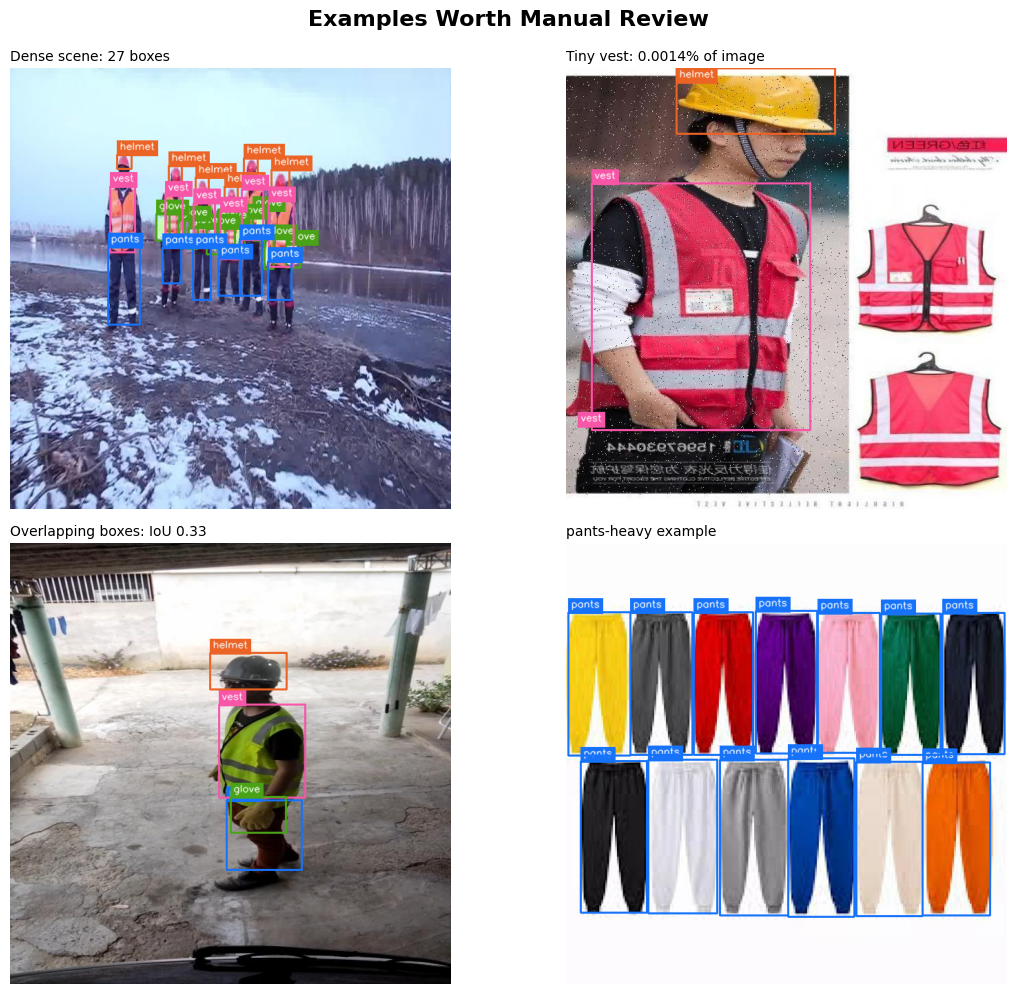

In [16]:
hard_examples, hard_reasons = choose_challenging_examples(image_df, box_df)
display(hard_reasons)
show_image_grid(hard_examples, "Examples Worth Manual Review", columns=2, figsize=(12, 10))


## Dataset Notes

- The dataset has **1,644 images** split into **1,152 train**, **328 validation**, and **164 test** images.
- The labels cover **4 classes** and **4,298 annotation rows**.
- The class distribution is mildly imbalanced: **glove** has **1,293** labels and **pants** has **909**, a **1.42:1** ratio.
- I found no missing label files, empty label files, or malformed label rows after accounting for polygon-style annotations.
- The export contains both standard YOLO box rows and polygon rows. For detection EDA, I convert each polygon to its bounding-box extent.
- The image-size check confirms the export is consistently resized, which keeps preprocessing simple.
- The manual-review examples highlight the main dataset risks: crowded scenes, very small labeled objects, overlapping annotations, and coverage for the least frequent class.


## Why this Matters

The dataset is suitable for a baseline detector because all images are consistently resized to 640x640 and the class imbalance is mild. The main expected modeling challenges are small objects, dense scenes, and overlapping PPE regions. Because gloves and pants have weaker visual coverage and smaller regions, I expect these classes to be more difficult than helmets and vests. These findings motivate tracking per-class recall and manually reviewing low-confidence or missed detections after deployment.